23070521196 - Pinak Rokde

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import layers, models, regularizers, callbacks

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
data = pd.read_csv("Housing.csv")
display(data.head())
print("Shape:", data.shape)
print("Columns:", list(data.columns))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Convert yes/no and category columns into numbers
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop("price", axis=1)
y = data_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train_scaled.shape[0])
print("Test rows:", X_test_scaled.shape[0])
print("Number of input features:", X_train_scaled.shape[1])

Training rows: 436
Test rows: 109
Number of input features: 13


In [6]:
def build_model(reg_type=None, dropout_rate=0.0):
    """Create a small neural network for house price prediction."""
    if reg_type == "l1":
        kernel_reg = regularizers.l1(1e-4)
    elif reg_type == "l2":
        kernel_reg = regularizers.l2(1e-4)
    else:
        kernel_reg = None

    model = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu", kernel_regularizer=kernel_reg),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu", kernel_regularizer=kernel_reg),
        layers.Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    return model

def train_and_score(model, name):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    predictions = model.predict(X_test_scaled, verbose=0).ravel()
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"{name}: RMSE={rmse:,.2f}, MAE={mae:,.2f}, R2={r2:.3f}")
    return history, {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [7]:
baseline_model = build_model()
baseline_history, baseline_result = train_and_score(baseline_model, "Baseline")

Baseline: RMSE=5,396,062.81, MAE=4,933,221.00, R2=-4.761


In [8]:
l2_model = build_model(reg_type="l2")
l2_history, l2_result = train_and_score(l2_model, "L2 Regularization")

l1_model = build_model(reg_type="l1")
l1_history, l1_result = train_and_score(l1_model, "L1 Regularization")

L2 Regularization: RMSE=5,394,293.79, MAE=4,932,619.50, R2=-4.757


L1 Regularization: RMSE=5,411,098.74, MAE=4,944,011.50, R2=-4.793


In [9]:
dropout_model = build_model(dropout_rate=0.2)
dropout_history, dropout_result = train_and_score(dropout_model, "Dropout")

Dropout: RMSE=5,393,346.27, MAE=4,932,516.50, R2=-4.755


,Model,RMSE,MAE,R2
3,Dropout,5.393346e+06,4932516.5,-4.754828
1,L2 Regularization,5.394294e+06,4932619.5,-4.756851
0,Baseline,5.396063e+06,4933221.0,-4.760627
2,L1 Regularization,5.411099e+06,4944011.5,-4.792775


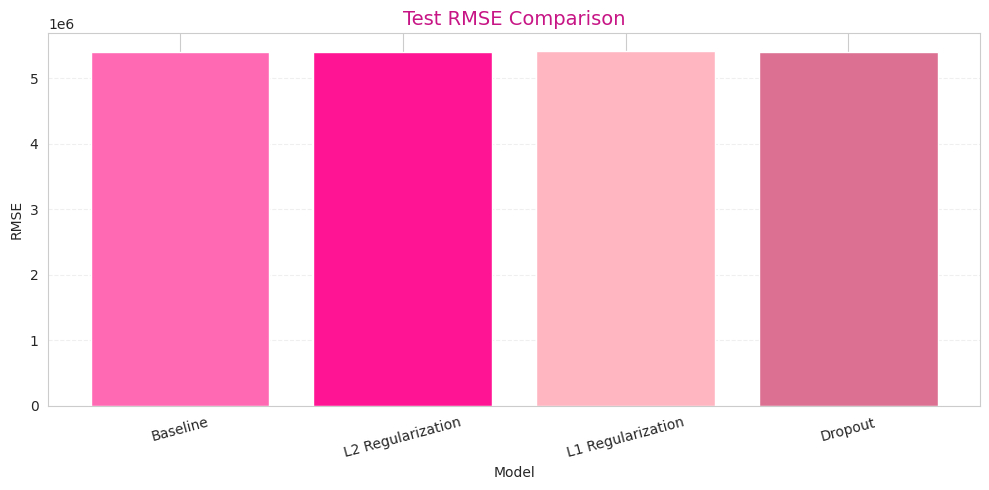

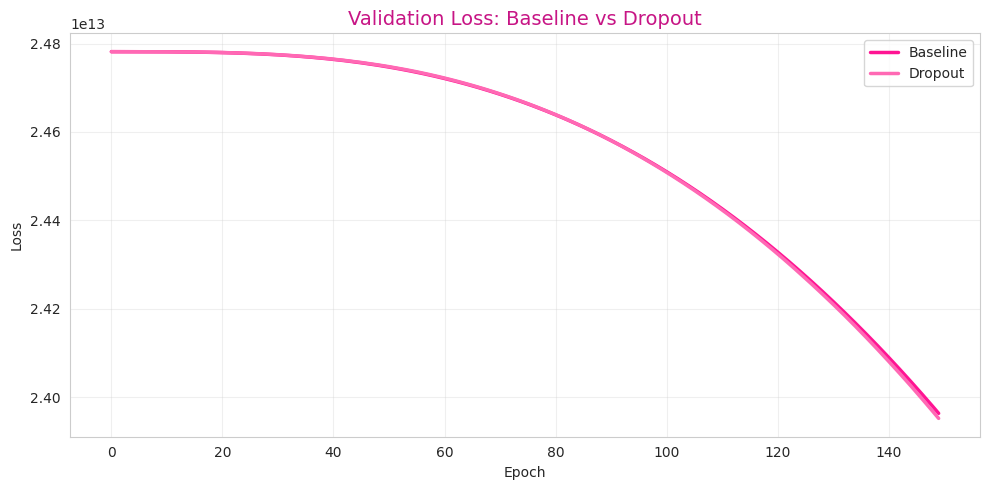

In [11]:
results = pd.DataFrame([baseline_result, l2_result, l1_result, dropout_result])
display(results.sort_values("RMSE"))


plt.figure(figsize=(10, 5))
palette = ["#FF69B4", "#FF1493", "#FFB6C1", "#DB7093"]
plt.bar(results["Model"], results["RMSE"], color=palette)
plt.title("Test RMSE Comparison", fontsize=14, color="#C71585")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(
    baseline_history.history["val_loss"],
    label="Baseline",
    color="#FF1493",
    linewidth=2.5
)
plt.plot(
    dropout_history.history["val_loss"],
    label="Dropout",
    color="#FF69B4",
    linewidth=2.5
)
plt.title("Validation Loss: Baseline vs Dropout", fontsize=14, color="#C71585")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()